# 01 · Entendimiento de los datos

Plantilla de inspección. Ejecutar desde la carpeta `notebooks/`. Completar las observaciones después de revisar los resultados. No se eliminan datos ni se aplican transformaciones de limpieza.

## 1. Importación de librerías

In [24]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow
from scipy import stats

## 2. Carga del archivo Parquet

In [25]:
# Sustituir el nombre por el archivo real ubicado en data/.
ruta_datos = Path("../data/secop_bienes.parquet")
if not ruta_datos.is_file():
    raise FileNotFoundError(f"Coloca el archivo en data/ y actualiza su nombre: {ruta_datos}")

df = pd.read_parquet(ruta_datos)
df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


## 3. Dimensiones del dataset

In [26]:
pd.Series({"filas": df.shape[0], "columnas": df.shape[1]})

filas       196391
columnas        36
dtype: int64

## 4. Tipos de datos

In [27]:
df.dtypes.to_frame(name="tipo_de_dato")

,tipo_de_dato
id_contrato,object
nombre_entidad,object
departamento,object
ciudad,object
orden,object
sector,object
rama,object
entidad_centralizada,object
tipo_de_contrato,object
modalidad_de_contratacion,object


## 5. Valores nulos

In [28]:
pd.DataFrame({
    "cantidad_nulos": df.isna().sum(),
    "porcentaje_nulos": df.isna().mean() * 100,
})

,cantidad_nulos,porcentaje_nulos
id_contrato,0,0.000000
nombre_entidad,0,0.000000
departamento,0,0.000000
ciudad,0,0.000000
orden,0,0.000000
sector,0,0.000000
rama,0,0.000000
entidad_centralizada,0,0.000000
tipo_de_contrato,0,0.000000
modalidad_de_contratacion,0,0.000000


## 6. Valores únicos

In [29]:
# Los nulos se excluyen del conteo; se inspeccionan en la sección anterior.
df.nunique(dropna=True).to_frame(name="valores_unicos_sin_nulos")

,valores_unicos_sin_nulos
id_contrato,196391
nombre_entidad,3452
departamento,34
ciudad,676
orden,4
sector,26
rama,5
entidad_centralizada,2
tipo_de_contrato,2
modalidad_de_contratacion,9


## 7. Duplicados

In [30]:
# Coincidencia de todas las columnas, sin considerar el índice.
# Solo se cuentan e inspeccionan; no se elimina ninguna fila.
pd.Series({
    "repeticiones_despues_de_la_primera": df.duplicated().sum(),
    "filas_en_grupos_duplicados": df.duplicated(keep=False).sum(),
})

repeticiones_despues_de_la_primera    0
filas_en_grupos_duplicados            0
dtype: int64

In [34]:
# Vista previa de filas duplicadas, conservando el dataset original.
df.loc[df.duplicated(keep=False)].head(20)

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso


## 8. Estadísticos descriptivos

In [32]:
if df.shape[1] > 0:
    display(df.describe(include="all"))
else:
    print("El dataset no contiene columnas para describir.")

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
count,196391,196391,196391,196391,196391,196391,196391,196391,196391,196391,...,1.963910e+05,196391.000000,196391,196391,196391,196391,196391,196391,196391,196391
unique,196391,3452,34,676,4,26,5,2,2,9,...,NaN,NaN,3,2,2,4,9,2,2,183042
top,CO1.PCCNTR.1000001,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,No Definido,Territorial,Servicio Público,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,NaN,NaN,No,No,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
freq,1,3416,52297,41672,97293,37390,157365,156160,106632,117753,...,NaN,NaN,167549,157979,158862,117097,54230,118418,187770,261
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.570476e+10,5.107485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.418488e+07,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.717571e+06,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.241189e+07,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.285845e+16,14276.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 8.1. Validacion: fecha de fin anterior a fecha de inicio

Se cuentan y muestran las inconsistencias sin eliminar ni modificar registros. Los casos con fechas faltantes se reportan aparte.

In [33]:
# Solo se comparan registros que tienen ambas fechas.
fechas_completas = df[[
    "fecha_de_inicio_del_contrato", "fecha_de_fin_del_contrato"
]].notna().all(axis=1)
fin_antes_de_inicio = fechas_completas & (
    df["fecha_de_fin_del_contrato"] < df["fecha_de_inicio_del_contrato"]
)

resumen_fechas = pd.Series({
    "registros_evaluados": int(fechas_completas.sum()),
    "registros_sin_alguna_fecha": int((~fechas_completas).sum()),
    "fin_anterior_al_inicio": int(fin_antes_de_inicio.sum()),
    "porcentaje_sobre_evaluados": (
        fin_antes_de_inicio.sum() / fechas_completas.sum() * 100
        if fechas_completas.any() else float("nan")
    ),
})
display(resumen_fechas.to_frame(name="valor"))

# Se conservan todos los casos para inspeccion; la tabla muestra los primeros 20.
contratos_fechas_inconsistentes = df.loc[fin_antes_de_inicio].copy()
display(contratos_fechas_inconsistentes[[
    "fecha_de_inicio_del_contrato", "fecha_de_fin_del_contrato"
]].head(20))


,valor
registros_evaluados,193951.000000
registros_sin_alguna_fecha,2440.000000
fin_anterior_al_inicio,125.000000
porcentaje_sobre_evaluados,0.064449


,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato
20778,2021-03-16,2020-12-01
21873,2021-03-15,2020-12-01
43226,2021-10-29,2021-09-30
48983,2022-12-01,2021-12-30
52996,2022-01-05,2021-12-31
53371,2022-03-01,2022-01-07
64215,2023-07-27,2022-08-26
68787,2022-12-23,2022-12-15
95083,2024-07-05,2023-07-20
121713,2024-04-25,2024-04-24


### 8.2. Contratos terminados, liquidados y con dias adicionados por anio

Porcentajes sobre el total de firmas de cada anio, contando cada fila. Terminados: estado_contrato igual a "terminado". Liquidados: liquidaci_n igual a "Si". Con dias adicionados: dias_adicionados mayor que cero. Estos indicadores pueden coincidir en un mismo contrato y no tienen que sumar 100%. Se describe el estado registrado en el dataset, agrupado por anio de firma.

In [ ]:
# Indicadores sobre el total de firmas de cada anio.
indicadores_estado = pd.DataFrame({
    "anio_firma": df["fecha_de_firma"].dt.year.astype("Int64"),
    "terminado": df["estado_contrato"].astype("string").str.strip().str.casefold()
        .eq("terminado").fillna(False),
    "liquidado": df["liquidaci_n"].astype("string").str.strip().str.casefold()
        .isin(["si", "sí"]),
    "con_dias_adicionados": df["dias_adicionados"].gt(0).fillna(False),
})
resumen_estado_por_anio = (
    indicadores_estado.groupby("anio_firma", dropna=False)
    .agg(
        cantidad_firmas=("terminado", "size"),
        porcentaje_terminados=("terminado", "sum"),
        porcentaje_liquidados=("liquidado", "sum"),
        porcentaje_con_dias_adicionados=("con_dias_adicionados", "sum"),
    )
    .sort_index()
    .reset_index()
)
columnas_estado_pct = [
    "porcentaje_terminados", "porcentaje_liquidados", "porcentaje_con_dias_adicionados"
]
resumen_estado_por_anio[columnas_estado_pct] = (
    resumen_estado_por_anio[columnas_estado_pct]
    .div(resumen_estado_por_anio["cantidad_firmas"], axis=0) * 100
)
display(resumen_estado_por_anio.style.format({
    columna: "{:.2f}%" for columna in columnas_estado_pct
}))


,anio_firma,cantidad_firmas,porcentaje_terminados,porcentaje_liquidados,porcentaje_con_dias_adicionados
0,2019,16425,17.33%,38.57%,4.18%
1,2020,20135,21.53%,31.11%,7.76%
2,2021,24043,27.00%,28.53%,7.43%
3,2022,28070,29.40%,33.33%,6.69%
4,2023,32971,31.42%,42.77%,7.84%
5,2024,34634,32.93%,46.51%,9.35%
6,2025,40113,26.27%,47.23%,17.29%


## 9. Observaciones

### Problemas de calidad identificados de manera preliminar y su tratamiento propuesto

- fecha_de_inicio_del_contrato presenta 2.440 valores faltantes, equivalentes aproximadamente al 1,24 % de los registros. 
    - Los registros se excluirán únicamente de los análisis que requieran esta fecha, a menos que exista otra variable confiable que permita recuperarla.
- documento_proveedor presenta 4 valores faltantes, equivalentes aproximadamente al 0,002 %.
    - Mantener los registros si esta variable no es necesaria para el análisis. 

- en el atributo ciudad, el valor más frecuente es "No Definido". Aunque no está representado como NaN, puede corresponder a información no disponible y debe considerarse como tal en los análisis donde esta variable sea relevante.
    - Considerarlo como información no disponible y mantenerlo diferenciado de las ciudades válidas.

- **Posible violación de dominio:** valor_pendiente_de_pago presenta un valor mínimo aproximado de -8.42e+07. Debido a que un valor pendiente de pago negativo puede resultar inconsistente con la interpretación de la variable, se debe verificar antes de decidir su tratamiento.
    - Revisar el significado de la variable y contrastar el registro con otras variables monetarias antes de modificarlo o excluirlo. 

- **Valores atípicos:** valor_pendiente_de_pago alcanza un máximo aproximado de 1.29e+16, mientras que dias_adicionados alcanza un máximo de 14.276 días. Estos valores son extremadamente altos respecto al comportamiento general de las variables y deben revisarse para determinar si corresponden a casos reales o a errores de registro.
    - Validar su coherencia con otras variables del contrato. No eliminarlos únicamente por ser valores atípicos. 

- **Violación de integridad a nivel de registro:** se identificaron 125 contratos cuya fecha_de_fin_del_contrato es anterior a la fecha_de_inicio_del_contrato. Un contrato no debería finalizar antes de su fecha de inicio.
    - Excluir estos registros de análisis que dependan de duración o relaciones temporales si no es posible corregirlos con información confiable.


### Selección de 5 atributos

1. **Valor del contrato**
   - Para analizar si la magnitud económica del contrato está asociada con una mayor o menor ocurrencia de desviaciones respecto al plan inicial (adiciones de plazo, diferencias en el valor pagado o falta de liquidación).

2. **Sector**
   - Para analizar si las desviaciones se comportan de manera diferente entre distintos sectores a los que pertenecen las entidades contratantes.

3. **Modalidad de contratación**
   - Para analizar si ciertas modalidades de contratación están asociadas con una mayor o menor ocurrencia de desviaciones durante la ejecución del contrato.

4. **Días adicionados**
   - Para identificar y caracterizar las ampliaciones del plazo inicialmente establecido, ya que estas representan una de las posibles desviaciones del plan original del contrato.

5. **Liquidación**
   - Para analizar si los contratos finalizan con su proceso de liquidación o si existen contratos que terminan sin liquidarse, lo cual constituye otra de las desviaciones de interés planteadas en el problema.


### Análisis univariado de los 5 atributos


#### Atributo 1: Valor del contrato

In [42]:
df["valor_del_contrato"].describe()

count    1.963910e+05
mean     6.582426e+10
std      2.901535e+13
min      0.000000e+00
25%      1.202121e+07
50%      3.360000e+07
75%      1.000000e+08
max      1.285845e+16
Name: valor_del_contrato, dtype: float64

In [ ]:
# Inspeccion de contratos con valor exactamente igual a cero.
valor_cero = df["valor_del_contrato"].eq(0).fillna(False)
resumen_valor_cero = pd.DataFrame({
    "cantidad_valor_cero": [int(valor_cero.sum())],
    "porcentaje_sobre_total": [100 * valor_cero.sum() / len(df) if len(df) else float("nan")],
})
display(resumen_valor_cero)


cantidad_valor_cero,porcentaje_sobre_total
188,0.095727


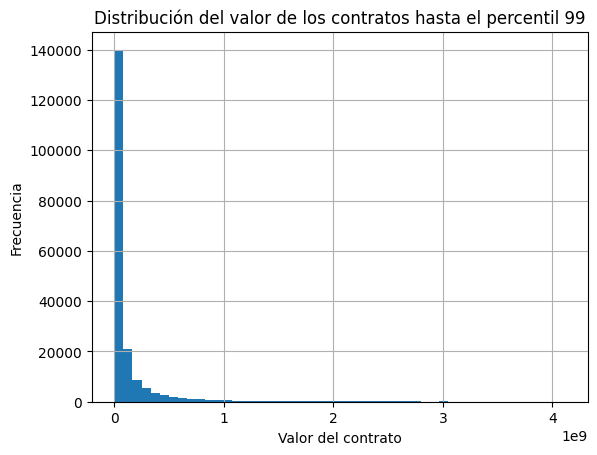

In [46]:
limite = df["valor_del_contrato"].quantile(0.99)

df.loc[
    df["valor_del_contrato"] <= limite,
    "valor_del_contrato"
].hist(bins=50)

plt.title("Distribución del valor de los contratos hasta el percentil 99")
plt.xlabel("Valor del contrato")
plt.ylabel("Frecuencia")
plt.show()

- **Tipo y significado:** Variable cuantitativa. Representa el valor económico inicialmente establecido para el contrato.

- **Estadísticos:** La mediana del valor de los contratos es de aproximadamente $33,6 millones. El 50 % de los contratos se encuentra entre aproximadamente $12 millones (Q1) y $100 millones (Q3). La media es considerablemente mayor, con aproximadamente $65.824 millones, lo que indica la influencia de valores extremadamente altos.

- **Gráfico e interpretación:** La distribución presenta una fuerte asimetría hacia la derecha. La mayoría de los contratos se concentra en valores relativamente bajos, mientras una pequeña cantidad presenta valores mucho mayores. Debido a esta diferencia de escala, los valores extremos comprimen la visualización del histograma.

- **Valores atípicos o limitaciones:** Se observa un valor máximo aproximado de $1,29 × 10^16, considerablemente superior al resto de la distribución. Este tipo de valores puede influir fuertemente en la media, por lo que la mediana resulta más representativa del comportamiento típico de la variable. Estos valores no deben eliminarse automáticamente sin verificar si corresponden a contratos reales o a problemas de calidad.

- **Valores iguales a cero:** Se identifican 188 contratos con valor igual a 0, equivalentes al 0.0957 % del total de registros. Son valores registrados, distintos de los nulos. Su interpretacion requiere revisar el contexto del contrato; no se eliminan ni modifican automaticamente.

#### Atributo 2: Sector

In [57]:
frecuencia_sector = df["sector"].value_counts()

display(frecuencia_sector)

sector
Servicio Público                                      37390
defensa                                               34585
No aplica/No pertenece                                24465
Salud y Protección Social                             22037
Ley de Justicia                                       20377
Trabajo                                               14759
Educación Nacional                                    10231
Ambiente y Desarrollo Sostenible                       8109
Transporte                                             4655
Cultura                                                2792
deportes                                               2610
Hacienda y Crédito Público                             2441
Industria                                              1807
Vivienda, Ciudad y Territorio                          1497
Planeación                                             1319
agricultura                                            1254
interior                         

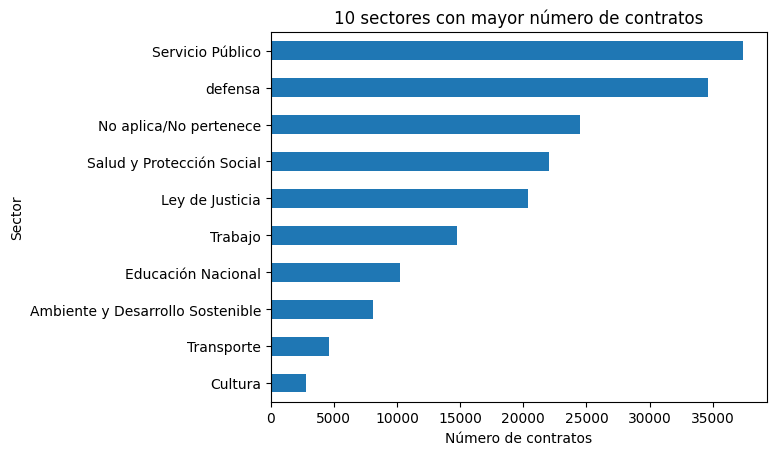

In [58]:
df["sector"].value_counts().head(10).sort_values().plot(
    kind="barh"
)

plt.title("10 sectores con mayor número de contratos")
plt.xlabel("Número de contratos")
plt.ylabel("Sector")
plt.show()

- **Tipo y significado:** Variable categórica nominal. Identifica el sector al que pertenece la entidad contratante.

- **Frecuencias:** Los sectores con mayor número de contratos son: Servicio Público, Defensa, No aplica/No pertenece, Salud y Protección Social y Ley de Justicia.

- **Gráfico e interpretación:** La distribución de los contratos entre sectores no es uniforme. Una parte importante de los contratos se concentra en unos pocos sectores, mientras que otros presentan una cantidad mucho menor de registros.

- **Valores nulos o atípicos y limitaciones:** Se identifican 9 registros con la categoría No Definido, que representa información no disponible y debe distinguirse de los sectores identificados.

#### Atributo 3: modalidad de contratación

In [59]:
frecuencia_modalidad = df["modalidad_de_contratacion"].value_counts()

display(frecuencia_modalidad)

modalidad_de_contratacion
Mínima cuantía                                                 117753
Selección abreviada subasta inversa                             32907
Contratación régimen especial                                   19250
Selección Abreviada de Menor Cuantía                             8822
Contratación régimen especial (con ofertas)                      6154
Contratación Directa (con ofertas)                               5001
Contratación directa                                             3938
Licitación pública                                               2330
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes       236
Name: count, dtype: int64

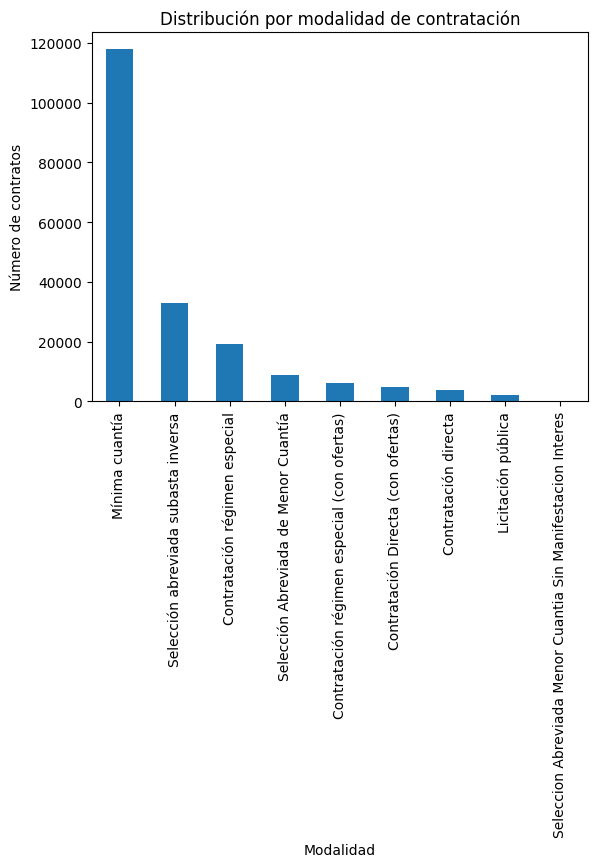

In [60]:
df["modalidad_de_contratacion"].value_counts().plot(kind="bar")

plt.title("Distribución por modalidad de contratación")
plt.xlabel("Modalidad")
plt.ylabel("Número de contratos")
plt.show()

 **Tipo y significado:** Variable categórica nominal. Indica la modalidad mediante la cual se realizó el proceso de contratación.

- **Frecuencias:** La modalidad más frecuente es Mínima cuantía, con 117.753 contratos, seguida por Selección abreviada subasta inversa, con 32.907, y Contratación régimen especial, con 19.250. Las demás modalidades presentan una frecuencia considerablemente menor.

- **Gráfico e interpretación:** La distribución presenta una alta concentración en Mínima cuantía, que agrupa por sí sola la mayoría de los registros. Después de esta modalidad, la frecuencia disminuye considerablemente, por lo que la distribución de los contratos entre las distintas modalidades no es uniforme.

- **Valores nulos o atípicos y limitaciones:** No se identificaron problemas relevantes para este atributo en la revisión realizada. No presenta valores nulos.

#### Atributo 4: Dias adicionados

In [61]:
df["dias_adicionados"].describe()

count    196391.000000
mean          5.107485
std          40.662426
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       14276.000000
Name: dias_adicionados, dtype: float64

In [67]:
porcentaje_con_adicion = (
    (df["dias_adicionados"] > 0).mean() * 100
)

print(f"Contratos con días adicionados: {porcentaje_con_adicion:.2f}%")

Contratos con días adicionados: 9.51%


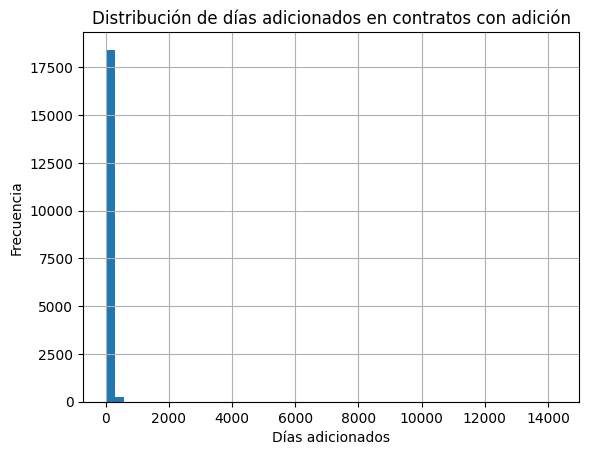

In [68]:
df.loc[
    df["dias_adicionados"] > 0,
    "dias_adicionados"
].hist(bins=50)

plt.title("Distribución de días adicionados en contratos con adición")
plt.xlabel("Días adicionados")
plt.ylabel("Frecuencia")
plt.show()

- **Tipo y significado:** Variable cuantitativa discreta. Representa la cantidad de días agregados al plazo inicialmente establecido del contrato.

- **Estadísticos:** El 9,51 % de los contratos presenta al menos un día adicionado, mientras que el 90,49 % no registra adiciones. La mediana y los cuartiles Q1 y Q3 son iguales a 0, lo que evidencia una alta concentración de contratos sin ampliaciones de plazo.

- **Gráfico e interpretación:** La distribución presenta una fuerte asimetría hacia la derecha. La mayoría de los contratos con adiciones concentra valores relativamente bajos, mientras que una cantidad reducida presenta extensiones considerablemente mayores.

- **Valores atípicos o limitaciones:** Se observa un máximo de 14.276 días, considerablemente superior al comportamiento general de la variable. Este valor debe validarse antes de ser interpretado.

- **Limitaciones para contrastar las adiciones con la duración:** En el dataset se identificaron 2.440 registros sin fecha de inicio y 125 con fecha de fin anterior a la de inicio. Si se usan estas fechas para validar los días adicionados o relacionarlos con la duración del contrato, deben identificarse los casos afectados y corregirse con información confiable o excluirse solo de esa comparación. Estos problemas no impiden contar directamente los días adicionados registrados.

#### Atributo 5: Liquidacion


In [69]:
df["liquidaci_n"].value_counts(dropna=False)

liquidaci_n
No    118418
Si     77973
Name: count, dtype: int64

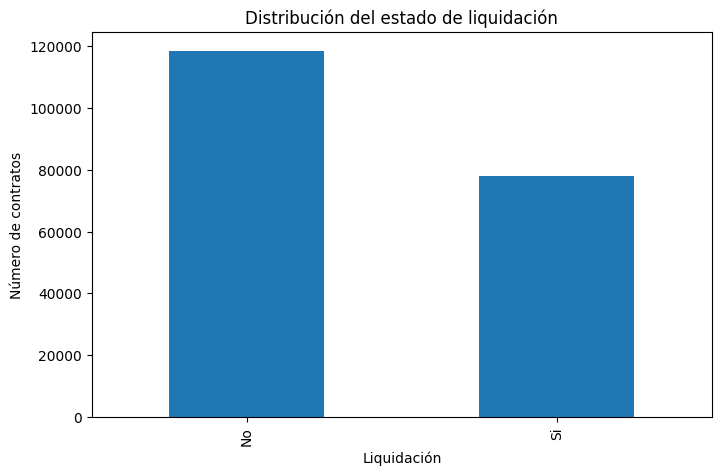

In [70]:
df["liquidaci_n"].value_counts(dropna=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución del estado de liquidación")
plt.xlabel("Liquidación")
plt.ylabel("Número de contratos")
plt.show()

- **Tipo y significado:** Variable categórica nominal dicotómica. Indica si el contrato registra liquidación.

- **Frecuencias:** Se registran 118.418 contratos con valor No y 77.973 contratos con valor Sí. Por lo tanto, predominan los contratos que no registran liquidación.

- **Gráfico e interpretación:** El gráfico de barras muestra una mayor frecuencia de contratos clasificados como No frente a los clasificados como Sí, evidenciando que la ausencia de liquidación es la categoría predominante en el conjunto de datos.

- **Valores nulos o limitaciones:** No se observan valores nulos ni categorías diferentes de Sí y No. Sin embargo, el valor No no debe interpretarse automáticamente como una desviación del contrato, ya que algunos contratos podrían encontrarse todavía en ejecución o no requerir liquidación en el momento del registro.